<a href="https://colab.research.google.com/github/nemanjabozilovic/StudentRecords/blob/master/notebooks/clothing-classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Provera da li je GPU dostupan# New Section

In [1]:
# Provera da li je GPU dostupan
import tensorflow as tf

print("TensorFlow verzija:", tf.__version__)
print("="*50)

# Provera GPU-a
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU je dostupan! Pronađeno {len(gpus)} GPU uređaj(a):")
    for gpu in gpus:
        print(f"  - {gpu.name}")
else:
    print("UPOZORENJE: GPU nije pronađen!")
    print("Idite na Runtime → Change runtime type → GPU")

TensorFlow verzija: 2.19.0
UPOZORENJE: GPU nije pronađen!
Idite na Runtime → Change runtime type → GPU


# Instalacija potrebnih biblioteka

In [2]:
# Instalacija potrebnih biblioteka
!pip install gradio gdown -q

print("Biblioteke instalirane!")# Instalacija potrebnih biblioteka
!pip install gradio gdown -q

print("Biblioteke instalirane!")

Biblioteke instalirane!
Biblioteke instalirane!


# Import svih potrebnih biblioteka# New Section

In [4]:
# Import svih potrebnih biblioteka
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import gdown

# TensorFlow i Keras (Google-ova biblioteka za Deep Learning)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Za evaluaciju
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Za rad sa slikama
from PIL import Image

import warnings
warnings.filterwarnings('ignore')

# Podešavanje za lepši prikaz grafika
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

print("Sve biblioteke su uspešno učitane!")

Sve biblioteke su uspešno učitane!


# Preuzimanje dataset-a sa Google Drive-a

In [5]:
# =====================================================
# PREUZIMANJE DATASETA SA GOOGLE DRIVE
# =====================================================
# Dataset je unapred pripremljen za ovu radionicu
# Preuzimanje traje oko 20-30 sekundi

import gdown
import zipfile
import os

# Google Drive FILE ID (ZIP fajl)
FILE_ID = '1YpceXZvh-8idz-nKDJjUh3-nrlVvhyYY'

print("Preuzimanje Fashion dataseta sa Google Drive...")
print("Ovo traje 20-30 sekundi...\n")

# Preuzimanje ZIP fajla
url = f'https://drive.google.com/uc?id={FILE_ID}'
output = 'fashion_dataset.zip'
gdown.download(url, output, quiet=False)

# Raspakivanje
print("\nRaspakivanje...")
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall('.')

# Brisanje ZIP-a da uštedimo prostor
os.remove(output)

print("✅ Dataset uspešno preuzet i raspakovan!")

Preuzimanje Fashion dataseta sa Google Drive...
Ovo traje 20-30 sekundi...



Downloading...
From: https://drive.google.com/uc?id=1YpceXZvh-8idz-nKDJjUh3-nrlVvhyYY
To: /content/fashion_dataset.zip
100%|██████████| 24.8M/24.8M [00:00<00:00, 149MB/s]



Raspakivanje...
✅ Dataset uspešno preuzet i raspakovan!


# Pronalaženje preuzetog dataseta

In [7]:
# Pronalaženje preuzetog dataseta
import os

def pronadji_dataset():
    """Pronalazi styles.csv i images folder."""
    # Mogući nazivi foldera nakon preuzimanja
    moguce_putanje = [
        'fashion_subset gdg',
        'fashion_subset',
        'fashion_dataset',
        'fashion-product-images-small'
    ]

    # Proveri svaku moguću putanju
    for folder in moguce_putanje:
        if os.path.exists(folder):
            styles = os.path.join(folder, 'styles.csv')
            images = os.path.join(folder, 'images')
            if os.path.exists(styles) and os.path.exists(images):
                return folder

    # Ako nije pronađeno, pretraži trenutni direktorijum
    for item in os.listdir('.'):
        if os.path.isdir(item):
            styles = os.path.join(item, 'styles.csv')
            images = os.path.join(item, 'images')
            if os.path.exists(styles) and os.path.exists(images):
                return item

    return None

DATASET_PATH = pronadji_dataset()

if DATASET_PATH:
    print(f"✅ Dataset pronađen: {DATASET_PATH}")
    print(f"\nSadržaj:")
    for item in os.listdir(DATASET_PATH):
        if not item.startswith('.'):
            print(f"  - {item}")
else:
    print("❌ Dataset nije pronađen!")
    print("Pokrenite prethodnu ćeliju za preuzimanje.")

✅ Dataset pronađen: fashion_subset gdg

Sadržaj:
  - images
  - styles.csv


# Definisanje putanja

In [9]:
# Definisanje putanja
STYLES_PATH = os.path.join(DATASET_PATH, 'styles.csv')
IMAGES_PATH = os.path.join(DATASET_PATH, 'images')

# Provera da images folder ima slike
if os.path.exists(IMAGES_PATH):
    num_images = len([f for f in os.listdir(IMAGES_PATH) if f.endswith('.jpg')])
    print(f"Pronađeno {num_images:,} slika u images folderu.")
else:
    # Možda je folder drugačije imenovan
    for item in os.listdir(DATASET_PATH):
        potential_path = os.path.join(DATASET_PATH, item)
        if os.path.isdir(potential_path):
            files = os.listdir(potential_path)
            if any(f.endswith('.jpg') for f in files):
                IMAGES_PATH = potential_path
                print(f"Slike pronađene u: {IMAGES_PATH}")
                break

Pronađeno 3,866 slika u images folderu.


# Učitavanje metapodataka

In [10]:
# Učitavanje metapodataka
print("Učitavanje metapodataka...")
df = pd.read_csv(STYLES_PATH, on_bad_lines='skip')

print(f"Učitano {len(df):,} proizvoda")
print(f"\nKolone: {list(df.columns)}")

Učitavanje metapodataka...
Učitano 3,866 proizvoda

Kolone: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


# Pregled podataka

In [11]:
# Pregled podataka
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012,Casual,Peter England Men Party Blue Jeans
1,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012,Casual,Puma Men Grey T-shirt
2,1855,Men,Apparel,Topwear,Tshirts,Grey,Summer,2011,Casual,Inkfruit Mens Chain Reaction T-shirt
3,9204,Men,Footwear,Shoes,Casual Shoes,Black,Summer,2011,Casual,Puma Men Future Cat Remix SF Black Casual Shoes
4,7990,Men,Apparel,Topwear,Tshirts,Navy Blue,Fall,2011,Sports,Fila Men's Round Neck Navy Blue T-shirt


# Pregled kategorija

In [12]:
# Pregled kategorija
print("Top 20 kategorija po broju proizvoda:")
print("="*50)
print(df['articleType'].value_counts().head(20))

Top 20 kategorija po broju proizvoda:
articleType
Tshirts         1500
Casual Shoes    1500
Jeans            608
Jackets          258
Name: count, dtype: int64


# Izbor i podešavanje imena klasa (kategorija)

In [14]:
# =====================================================
# IZBOR 4 KLASE ZA RADIONICU
# =====================================================

ODABRANE_KATEGORIJE = {
    'Tshirts': 'T-shirt',
    'Jeans': 'Jeans',
    'Casual Shoes': 'Sneakers',
    'Jackets': 'Jacket'
}

# Filtriranje
df_filtered = df[df['articleType'].isin(ODABRANE_KATEGORIJE.keys())].copy()
df_filtered['class_name'] = df_filtered['articleType'].map(ODABRANE_KATEGORIJE)

# Nazivi klasa i labele
IMENA_KLASA = ['T-shirt', 'Jeans', 'Sneakers', 'Jacket']
BROJ_KLASA = len(IMENA_KLASA)
label_map = {name: idx for idx, name in enumerate(IMENA_KLASA)}
df_filtered['label'] = df_filtered['class_name'].map(label_map)

print(f"Odabrano {len(df_filtered):,} proizvoda iz 4 klase:")
print(df_filtered['class_name'].value_counts())

Odabrano 3,866 proizvoda iz 4 klase:
class_name
T-shirt     1500
Sneakers    1500
Jeans        608
Jacket       258
Name: count, dtype: int64


# Podešavanje dimenzija slika

In [16]:
# Dimenzije slike
IMG_HEIGHT = 80
IMG_WIDTH = 60
IMG_CHANNELS = 3

print(f"Dimenzije slika: {IMG_HEIGHT}x{IMG_WIDTH} piksela")
print(f"Broj kanala: {IMG_CHANNELS} (RGB - u boji)")
print(f"Ukupno vrednosti po slici: {IMG_HEIGHT*IMG_WIDTH*IMG_CHANNELS:,}")

Dimenzije slika: 80x60 piksela
Broj kanala: 3 (RGB - u boji)
Ukupno vrednosti po slici: 14,400


# Funkcija za učitavanje slike

In [18]:
# Funkcija za učitavanje slike
def ucitaj_sliku(image_id, images_dir, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    """Učitava i resize-uje sliku."""
    img_path = os.path.join(images_dir, f"{image_id}.jpg")

    if not os.path.exists(img_path):
        return None

    try:
        img = Image.open(img_path).convert('RGB')
        img = img.resize((target_size[1], target_size[0]))
        return np.array(img)
    except:
        return None


# Učitavanje slika

In [20]:
# =====================================================
# UČITAVANJE SLIKA
# =====================================================

MAX_PER_CLASS = 1500  # Ograničenje za brže treniranje

print(f"Učitavanje do {MAX_PER_CLASS} slika po klasi...")
print("Ovo traje 1-2 minuta...\n")

slike = []
labele = []

for klasa_idx, klasa_ime in enumerate(IMENA_KLASA):
    df_klasa = df_filtered[df_filtered['class_name'] == klasa_ime].head(MAX_PER_CLASS)

    ucitano = 0
    for _, row in df_klasa.iterrows():
        img = ucitaj_sliku(row['id'], IMAGES_PATH)
        if img is not None:
            slike.append(img)
            labele.append(klasa_idx)
            ucitano += 1

    print(f"  {klasa_ime}: {ucitano} slika")

X = np.array(slike)
y = np.array(labele)

print(f"\nUKUPNO: {len(X):,} slika")
print(f"Dimenzije: {X.shape}")
print(f"Memorija: {X.nbytes / (1024**2):.1f} MB")

Učitavanje do 1500 slika po klasi...
Ovo traje 1-2 minuta...

  T-shirt: 1500 slika
  Jeans: 608 slika
  Sneakers: 1500 slika
  Jacket: 258 slika

UKUPNO: 3,866 slika
Dimenzije: (3866, 80, 60, 3)
Memorija: 53.1 MB


# Vizualizacija primera

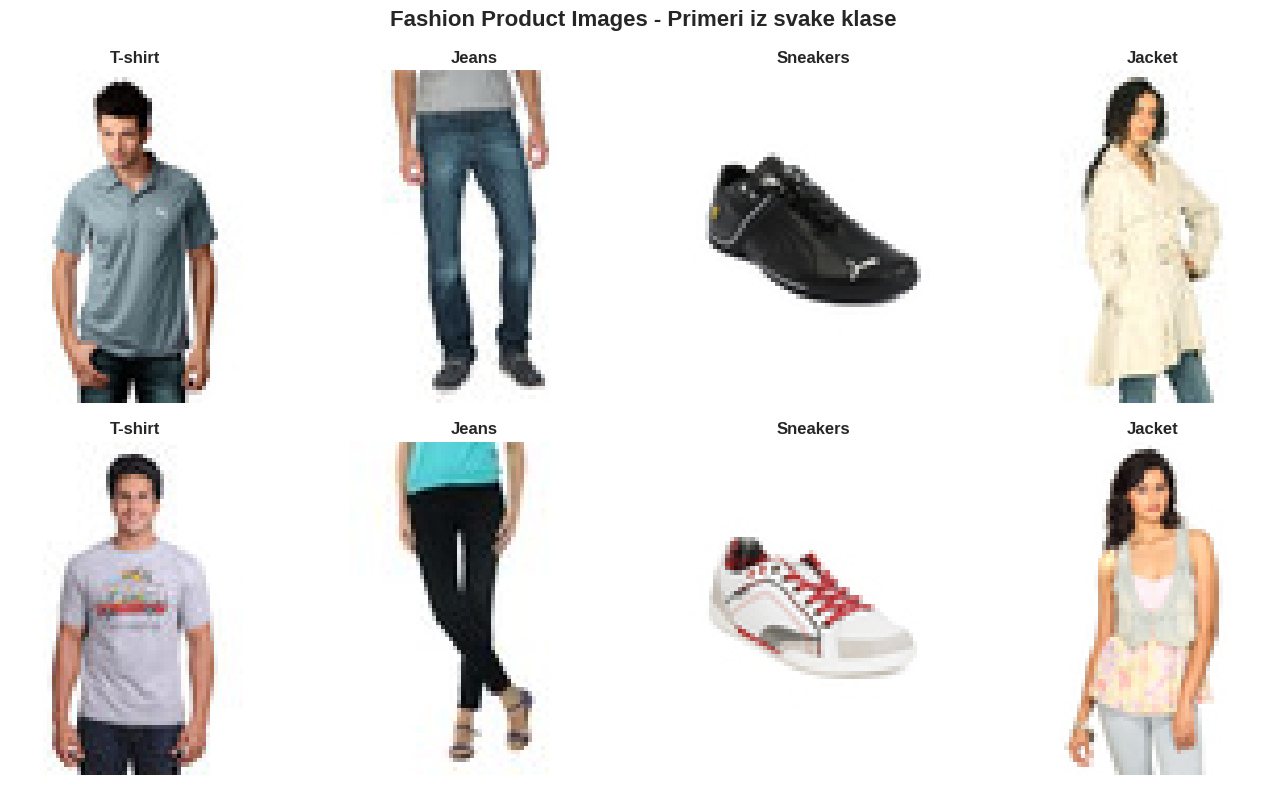


 Primećujete kako su ovo prave fotografije proizvoda!


In [27]:
# Vizualizacija primera
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
fig.suptitle('Fashion Product Images - Primeri iz svake klase', fontsize=16, fontweight='bold')

for klasa in range(BROJ_KLASA):
    indeksi = np.where(y == klasa)[0][:2]
    for j, idx in enumerate(indeksi):
        ax = axes[j, klasa]
        ax.imshow(X[idx])
        ax.set_title(f'{IMENA_KLASA[klasa]}', fontsize=12, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

print("\n Primećujete kako su ovo prave fotografije proizvoda!")


# Normalizacija

In [23]:

# Normalizacija
print("Pre normalizacije:")
print(f"  Min: {X.min()}, Max: {X.max()}")

X = X.astype('float32') / 255.0

print("\nPosle normalizacije:")
print(f"  Min: {X.min():.2f}, Max: {X.max():.2f}")

Pre normalizacije:
  Min: 0, Max: 255

Posle normalizacije:
  Min: 0.00, Max: 1.00


# Podela podataka: 70% train, 15% validation, 15% test

In [24]:
# Podela podataka: 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print("Podela podataka:")
print("="*50)
print(f"  Trening:    {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Validation: {len(X_val):,} ({len(X_val)/len(X)*100:.0f}%)")
print(f"  Test:       {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)")

Podela podataka:
  Trening:    2,707 (70%)
  Validation: 579 (15%)
  Test:       580 (15%)


# Distribucija klasa

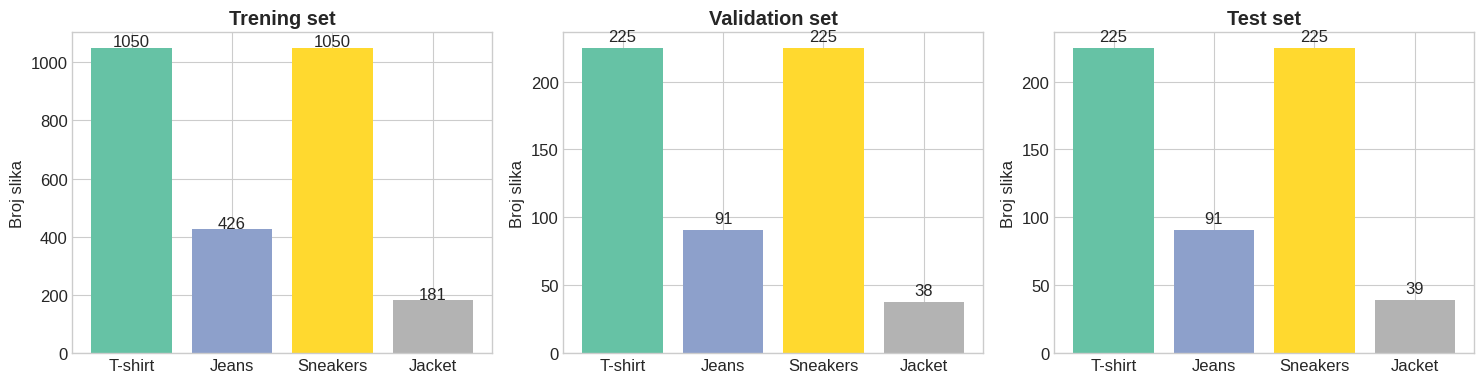


✅ Podaci spremni za treniranje!


In [25]:
# Distribucija klasa
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = plt.cm.Set2(np.linspace(0, 1, BROJ_KLASA))

for ax, (data, name) in zip(axes, [(y_train, 'Trening'), (y_val, 'Validation'), (y_test, 'Test')]):
    unique, counts = np.unique(data, return_counts=True)
    bars = ax.bar([IMENA_KLASA[i] for i in unique], counts, color=colors)
    ax.set_title(f'{name} set', fontweight='bold')
    ax.set_ylabel('Broj slika')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), ha='center')

plt.tight_layout()
plt.show()

print("\n✅ Podaci spremni za treniranje!")

# New Section